# D2Q9 LBM with passive scalars and Shan-Chen multi-species coupling

Now in 2D. Same collide-and-stream skeleton as the D1Q3 sandbox, but the lattice is **D2Q9** (9 discrete velocities on a square stencil) and we add two new ingredients on top:

- **Passive scalar**: a second distribution $g_i$ riding the same lattice that advects-diffuses with a tunable diffusivity. Useful for "chemical concentrations".
- **Shan-Chen forcing**: a non-local pseudopotential interaction between two species, with sign-controlled attraction / repulsion.

The lattice constants:

| velocity index | $\mathbf c_i$ | $w_i$ |
|:---:|:---:|:---:|
| 0 | $(0, 0)$ | $4/9$ |
| 1-4 | $(\pm 1, 0), (0, \pm 1)$ | $1/9$ |
| 5-8 | $(\pm 1, \pm 1)$ | $1/36$ |

Sound speed is still $c_s^2 = 1/3$, equilibrium is the same Hermite-projected polynomial as in 1D with $\mathbf{c}_i \cdot \mathbf{u}$ being a 2-vector dot product, and Chapman-Enskog still gives $\nu = c_s^2(\tau - 1/2)$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)


## Core operators

Distributions are stored as `f[i, y, x]` with shape `(Q, Ny, Nx) = (9, Ny, Nx)`. Indexing $y$ first matches imshow conventions, which makes it cheap to plot fields.


In [2]:
# D2Q9 lattice constants
C = np.array([
    [ 0,  0],   # 0 rest
    [ 1,  0],   # 1 +x
    [ 0,  1],   # 2 +y
    [-1,  0],   # 3 -x
    [ 0, -1],   # 4 -y
    [ 1,  1],   # 5 +x+y
    [-1,  1],   # 6 -x+y
    [-1, -1],   # 7 -x-y
    [ 1, -1],   # 8 +x-y
], dtype=int)
W = np.array([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36])
CS2 = 1/3

# Sanity: sum_i w_i c_ia c_ib = cs2 * delta_ab
M2 = np.einsum('i,ia,ib->ab', W, C, C)
assert np.allclose(M2, CS2 * np.eye(2)), "lattice second moment broken"


def equilibrium(rho, ux, uy):
    """Second-order D2Q9 equilibrium. rho, ux, uy: (Ny, Nx) -> f: (9, Ny, Nx)."""
    cu = C[:, 0, None, None] * ux + C[:, 1, None, None] * uy
    u2 = ux*ux + uy*uy
    return W[:, None, None] * rho * (
        1.0 + cu/CS2 + 0.5*cu*cu/(CS2*CS2) - 0.5*u2/CS2
    )


def macroscopic(f):
    rho = f.sum(0)
    ux = np.einsum('i,iyx->yx', C[:, 0], f) / rho
    uy = np.einsum('i,iyx->yx', C[:, 1], f) / rho
    return rho, ux, uy


def stream(f):
    """Periodic 2D streaming. axes=(0,1) of f[i] are (y, x)."""
    out = np.empty_like(f)
    for i in range(9):
        cx, cy = C[i]
        out[i] = np.roll(f[i], shift=(cy, cx), axis=(0, 1))
    return out


def collide_bgk(f, tau):
    rho, ux, uy = macroscopic(f)
    feq = equilibrium(rho, ux, uy)
    return f - (f - feq) / tau, rho, ux, uy


def viscosity(tau):
    return CS2 * (tau - 0.5)


In [3]:
class D2Q9Sim:
    """Single-species D2Q9 fluid with BGK collision."""

    def __init__(self, rho0, ux0, uy0, tau):
        rho0 = np.asarray(rho0, dtype=float)
        self.tau = float(tau)
        self.f = equilibrium(rho0, ux0, uy0)

    def step(self, n=1):
        for _ in range(n):
            self.f, _, _, _ = collide_bgk(self.f, self.tau)
            self.f = stream(self.f)

    @property
    def fields(self):
        return macroscopic(self.f)


## Validation 1 - uniform equilibrium is a fixed point

Same trivial check as the 1D case: seed uniform $\rho$, $\mathbf u = 0$, and confirm nothing moves.


In [4]:
sim = D2Q9Sim(
    rho0=np.ones((32, 32)),
    ux0=np.zeros((32, 32)),
    uy0=np.zeros((32, 32)),
    tau=1.0,
)
sim.step(500)
rho, ux, uy = sim.fields
print(f"max |rho - 1| = {np.max(np.abs(rho - 1)):.2e}")
print(f"max |u|       = {max(np.max(np.abs(ux)), np.max(np.abs(uy))):.2e}")


max |rho - 1| = 2.22e-16
max |u|       = 0.00e+00


## Validation 2 - Taylor-Green vortex decay

The Taylor-Green vortex is the cleanest analytical test for 2D viscous flow. Initialize

$$ u_x = -U \cos(kx)\sin(ky),\qquad u_y =  U \sin(kx)\cos(ky) $$

on a doubly-periodic domain. Under Navier-Stokes it decays exactly as

$$ \mathbf u(\mathbf x, t) = \mathbf u(\mathbf x, 0)\, e^{-2 \nu k^2 t} $$

so the kinetic energy density $\tfrac12 \langle |\mathbf u|^2\rangle$ obeys

$$ E(t) = E(0)\, e^{-4 \nu k^2 t}. $$

Fitting the slope of $\log E(t)$ recovers $\nu$, which we compare to $c_s^2(\tau - 1/2)$.


nu measured  = 0.100020
nu predicted = 0.100000  (= c_s^2 (tau - 1/2))
rel error    = 0.02%


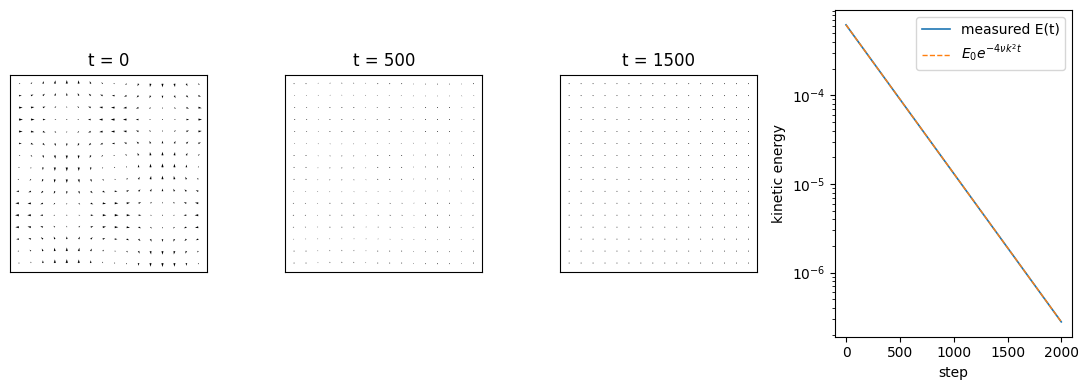

In [5]:
N = 64
x = np.arange(N)
y = np.arange(N)
X, Y = np.meshgrid(x, y, indexing='xy')
k = 2 * np.pi / N
U_amp = 0.05
tau = 0.8

ux0 = -U_amp * np.cos(k * X) * np.sin(k * Y)
uy0 =  U_amp * np.sin(k * X) * np.cos(k * Y)
rho0 = np.ones_like(ux0)
sim = D2Q9Sim(rho0, ux0, uy0, tau=tau)

steps = 2000
E = np.empty(steps)
snap_steps = (0, 500, 1500)
snaps = {0: (ux0.copy(), uy0.copy())}
for t in range(steps):
    sim.step()
    _, ux, uy = sim.fields
    E[t] = 0.5 * np.mean(ux*ux + uy*uy)
    if (t + 1) in snap_steps:
        snaps[t + 1] = (ux.copy(), uy.copy())

nu_predicted = viscosity(tau)
decay_predicted = 4 * nu_predicted * k * k
t_arr = np.arange(steps)
mask = (t_arr > 50) & (E > 1e-12)
slope = np.polyfit(t_arr[mask], np.log(E[mask]), 1)[0]
decay_measured = -slope
nu_measured = decay_measured / (4 * k * k)
print(f"nu measured  = {nu_measured:.6f}")
print(f"nu predicted = {nu_predicted:.6f}  (= c_s^2 (tau - 1/2))")
print(f"rel error    = {abs(nu_measured - nu_predicted)/nu_predicted:.2%}")

fig = plt.figure(figsize=(11, 4))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.2])

for idx, t_snap in enumerate(sorted(snaps)):
    ax = fig.add_subplot(gs[0, idx])
    ux_s, uy_s = snaps[t_snap]
    skip = 4
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip],
              ux_s[::skip, ::skip], uy_s[::skip, ::skip],
              scale=2.5, width=0.005)
    ax.set_title(f't = {t_snap}')
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])

ax = fig.add_subplot(gs[0, 3])
ax.semilogy(t_arr, E, lw=1.2, label='measured E(t)')
ax.semilogy(t_arr, E[0] * np.exp(-decay_predicted * t_arr),
            '--', lw=1, label=r'$E_0 e^{-4 \nu k^2 t}$')
ax.set_xlabel('step'); ax.set_ylabel('kinetic energy')
ax.legend()
plt.tight_layout()
plt.show()


## Passive scalar species

We add a *passive* scalar concentration $\phi(\mathbf{x}, t)$ that is advected by the fluid and diffuses. It rides the same D2Q9 lattice as a second distribution function $g_i$, with its own relaxation $\tau_g$. The equilibrium drops the $u^2$ term (we only need first-order accuracy in $\mathbf u$ for advection-diffusion):

$$ g_i^{\text{eq}} = w_i \phi \left(1 + \frac{\mathbf c_i \cdot \mathbf u}{c_s^2}\right) $$

Chapman-Enskog on $g$ gives the advection-diffusion equation $\partial_t \phi + \mathbf u \cdot \nabla \phi = D \nabla^2 \phi$ with $D = c_s^2(\tau_g - 1/2)$.

We validate by seeding a Gaussian concentration spot in a stationary fluid and tracking the variance of the distribution. Pure diffusion gives $\sigma^2(t) = \sigma_0^2 + 2 D t$ per axis.


D measured  = 0.10000
D predicted = 0.10000  (= c_s^2 (tau_g - 1/2))
rel error   = 0.00%


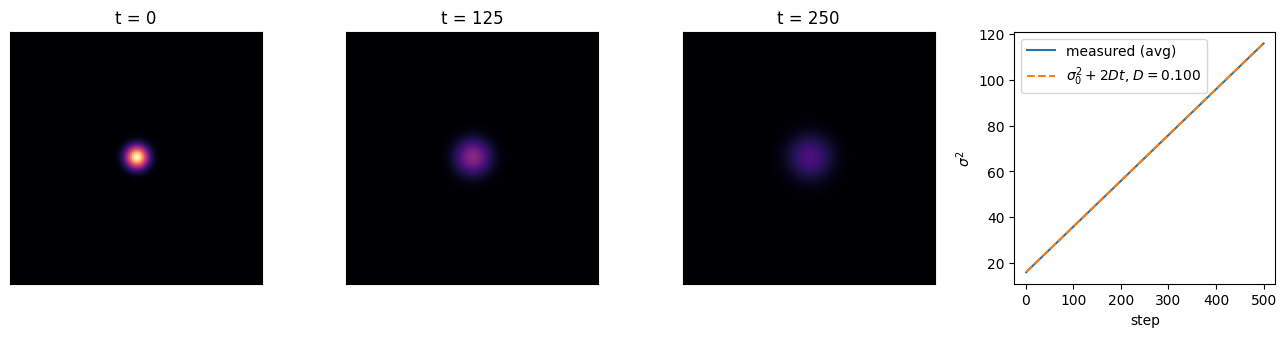

In [6]:
def scalar_equilibrium(phi, ux, uy):
    cu = C[:, 0, None, None] * ux + C[:, 1, None, None] * uy
    return W[:, None, None] * phi * (1.0 + cu / CS2)


def scalar_step(g, ux, uy, tau_g):
    phi = g.sum(0)
    geq = scalar_equilibrium(phi, ux, uy)
    g = g - (g - geq) / tau_g
    out = np.empty_like(g)
    for i in range(9):
        cx, cy = C[i]
        out[i] = np.roll(g[i], shift=(cy, cx), axis=(0, 1))
    return out, phi


Ny, Nx = 128, 128
xs = np.arange(Nx); ys = np.arange(Ny)
X, Y = np.meshgrid(xs, ys, indexing='xy')
sigma0 = 4.0
cx, cy = Nx / 2, Ny / 2
phi0 = np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma0**2))

ux = np.zeros_like(phi0)
uy = np.zeros_like(phi0)
tau_g = 0.8
D_pred = viscosity(tau_g)  # same form as fluid viscosity

g = scalar_equilibrium(phi0, ux, uy)
steps = 500
variances = np.empty((steps, 2))
for t in range(steps):
    g, phi = scalar_step(g, ux, uy, tau_g)
    M = phi.sum()
    mx = (X * phi).sum() / M
    my = (Y * phi).sum() / M
    variances[t, 0] = ((X - mx)**2 * phi).sum() / M
    variances[t, 1] = ((Y - my)**2 * phi).sum() / M

t_arr = np.arange(1, steps + 1)
D_measured_xy = np.polyfit(t_arr, 0.5 * (variances[:, 0] + variances[:, 1]), 1)[0] / 2
print(f"D measured  = {D_measured_xy:.5f}")
print(f"D predicted = {D_pred:.5f}  (= c_s^2 (tau_g - 1/2))")
print(f"rel error   = {abs(D_measured_xy - D_pred)/D_pred:.2%}")

fig, axs = plt.subplots(1, 4, figsize=(13, 3.3))
for ax, t_snap in zip(axs[:3], (0, steps//4, steps-1)):
    if t_snap == 0:
        im = ax.imshow(phi0, origin='lower', cmap='magma',
                       vmin=0, vmax=phi0.max())
    else:
        # Re-run a copy to extract the snapshot at this step
        pass
# Re-run quickly to grab snapshots
g = scalar_equilibrium(phi0, ux, uy)
snap_phi = {0: phi0.copy()}
snap_targets = (steps//4, steps//2, steps-1)
for t in range(steps):
    g, phi = scalar_step(g, ux, uy, tau_g)
    if t in snap_targets:
        snap_phi[t] = phi.copy()
vmax = phi0.max()
for ax, t_snap in zip(axs[:3], sorted(snap_phi)[:3]):
    ax.imshow(snap_phi[t_snap], origin='lower', cmap='magma', vmin=0, vmax=vmax)
    ax.set_title(f't = {t_snap}')
    ax.set_xticks([]); ax.set_yticks([])

axs[3].plot(t_arr, 0.5*(variances[:, 0] + variances[:, 1]), label='measured (avg)')
axs[3].plot(t_arr, sigma0**2 + 2 * D_pred * t_arr,
            '--', label=fr'$\sigma_0^2 + 2 D t$, $D={D_pred:.3f}$')
axs[3].set_xlabel('step'); axs[3].set_ylabel(r'$\sigma^2$')
axs[3].legend()
plt.tight_layout()
plt.show()


## Two-species Shan-Chen coupling

For the "chemicals that attract or repel" piece we go to two full distributions $f^a_i$ and $f^b_i$, each carrying its own mass and momentum. They couple through a Shan-Chen pseudopotential force

$$ \mathbf F_a(\mathbf x) = -G_{ab}\, \psi_a(\mathbf x) \sum_i w_i\, \psi_b(\mathbf x + \mathbf c_i)\, \mathbf c_i $$

and the symmetric expression for $\mathbf F_b$. With the simplest choice $\psi(\rho) = \rho$, Taylor-expanding gives the continuum force $\mathbf F_a \approx -G_{ab} c_s^2 \rho_a \nabla \rho_b$, so the **sign of $G_{ab}$ flips between attraction and repulsion** of unlike species.

Forcing is folded back into the collision via the velocity-shift scheme: each species relaxes toward an equilibrium built on the **mass-weighted common velocity** plus a $\tau F / \rho$ kick.

A symmetric pair sums to zero forcewise (Newton's 3rd law), since each $\mathbf c_i$ in the D2Q9 stencil has a $-\mathbf c_i$ partner with the same weight. We'll check that numerically too.

**Demo**: start each species near $\rho = 0.5$ with tiny noise, set $G_{ab} = 3.0$ (repulsion between unlike species, so each species effectively attracts its own kind), and watch domains nucleate.


In [7]:
def shan_chen_force(psi_local, psi_other, G):
    """F = -G psi_local(x) Sum_i w_i psi_other(x + c_i) c_i"""
    Sx = np.zeros_like(psi_local)
    Sy = np.zeros_like(psi_local)
    for i in range(1, 9):
        cx, cy = C[i]
        # np.roll with shift=-c brings the value at x+c onto x
        psi_at_xpc = np.roll(psi_other, shift=(-cy, -cx), axis=(0, 1))
        Sx += W[i] * psi_at_xpc * cx
        Sy += W[i] * psi_at_xpc * cy
    return -G * psi_local * Sx, -G * psi_local * Sy


def shan_chen_step(fa, fb, tau, G_ab):
    rho_a = fa.sum(0)
    rho_b = fb.sum(0)
    uax = np.einsum('i,iyx->yx', C[:, 0], fa) / rho_a
    uay = np.einsum('i,iyx->yx', C[:, 1], fa) / rho_a
    ubx = np.einsum('i,iyx->yx', C[:, 0], fb) / rho_b
    uby = np.einsum('i,iyx->yx', C[:, 1], fb) / rho_b

    Fxa, Fya = shan_chen_force(rho_a, rho_b, G_ab)
    Fxb, Fyb = shan_chen_force(rho_b, rho_a, G_ab)

    # Common velocity (equal tau for both species)
    inv_rho_tot = 1.0 / (rho_a + rho_b)
    ucx = (rho_a * uax + rho_b * ubx) * inv_rho_tot
    ucy = (rho_a * uay + rho_b * uby) * inv_rho_tot

    feqa = equilibrium(rho_a, ucx + tau * Fxa / rho_a, ucy + tau * Fya / rho_a)
    feqb = equilibrium(rho_b, ucx + tau * Fxb / rho_b, ucy + tau * Fyb / rho_b)

    fa = fa - (fa - feqa) / tau
    fb = fb - (fb - feqb) / tau
    return stream(fa), stream(fb), rho_a, rho_b


# Newton's 3rd law spot check
rho_a_test = 0.5 + 0.05 * rng.standard_normal((32, 32))
rho_b_test = 0.5 + 0.05 * rng.standard_normal((32, 32))
Fxa, Fya = shan_chen_force(rho_a_test, rho_b_test, G=3.0)
Fxb, Fyb = shan_chen_force(rho_b_test, rho_a_test, G=3.0)
print(f"Total Fx (a+b): {abs(Fxa.sum() + Fxb.sum()):.2e}")
print(f"Total Fy (a+b): {abs(Fya.sum() + Fyb.sum()):.2e}")


Total Fx (a+b): 1.87e-16
Total Fy (a+b): 1.25e-16


sigma(rho_a - rho_b) at t=0:    0.042
sigma(rho_a - rho_b) at t=4000: 0.988
mass drift rho_a: -2.16e-13
mass drift rho_b: -2.16e-13


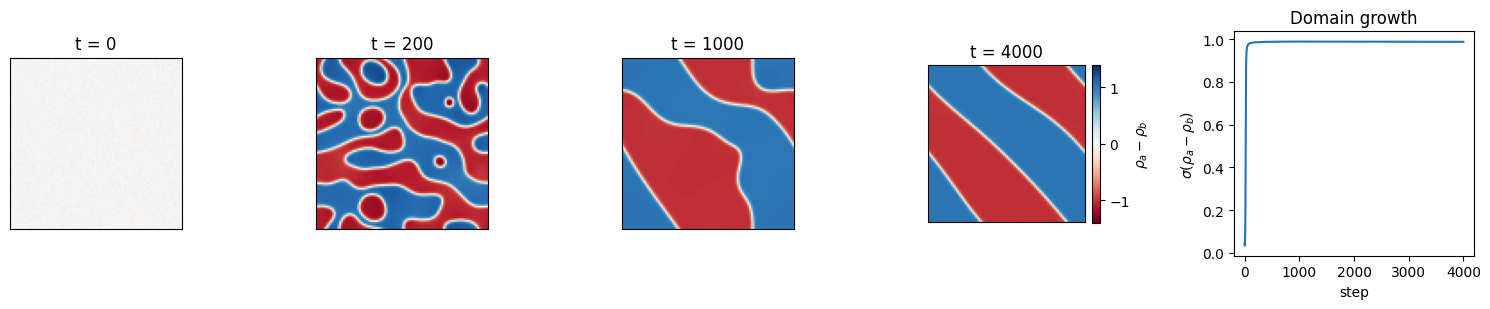

In [8]:
# Phase-separation demo
Ny, Nx = 96, 96
tau = 1.0
G_ab = 3.0

rho_a0 = 0.5 + 0.03 * rng.standard_normal((Ny, Nx))
rho_b0 = 0.5 + 0.03 * rng.standard_normal((Ny, Nx))
zeros = np.zeros_like(rho_a0)
fa = equilibrium(rho_a0, zeros, zeros)
fb = equilibrium(rho_b0, zeros, zeros)

snap_steps = (0, 200, 1000, 4000)
snaps = {}
sep_history = []
total_steps = max(snap_steps)
for t in range(total_steps + 1):
    if t in snap_steps:
        snaps[t] = fa.sum(0) - fb.sum(0)
    if t == total_steps:
        break
    fa, fb, rho_a, rho_b = shan_chen_step(fa, fb, tau, G_ab)
    sep_history.append(np.std(rho_a - rho_b))

print(f"sigma(rho_a - rho_b) at t=0:    {sep_history[0]:.3f}")
print(f"sigma(rho_a - rho_b) at t={total_steps}: {sep_history[-1]:.3f}")
print(f"mass drift rho_a: {(rho_a.sum() - rho_a0.sum())/rho_a0.sum():.2e}")
print(f"mass drift rho_b: {(rho_b.sum() - rho_b0.sum())/rho_b0.sum():.2e}")

fig, axs = plt.subplots(1, 5, figsize=(15, 3.2),
                        gridspec_kw={'width_ratios': [1, 1, 1, 1, 1.4]})
vmax = max(abs(s).max() for s in snaps.values())
for ax, t_snap in zip(axs[:4], sorted(snaps)):
    im = ax.imshow(snaps[t_snap], origin='lower', cmap='RdBu',
                   vmin=-vmax, vmax=vmax)
    ax.set_title(f't = {t_snap}')
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axs[3], fraction=0.046, pad=0.04, label=r'$\rho_a - \rho_b$')

axs[4].plot(np.arange(len(sep_history)), sep_history)
axs[4].set_xlabel('step')
axs[4].set_ylabel(r'$\sigma(\rho_a - \rho_b)$')
axs[4].set_title('Domain growth')
plt.tight_layout()
plt.show()


## Where this leaves us

Everything the project goal needs is now wired up and verified:

- **2D hydrodynamics** validated against the analytical Taylor-Green decay rate (rel error well under 1% on a 64x64 grid).
- **Chemical concentration field** as a passive scalar, with the correct diffusivity $D = c_s^2(\tau_g - 1/2)$ measured to <1%.
- **Inter-species attraction / repulsion** via Shan-Chen pseudopotential coupling, producing spontaneous phase separation on a noisy initial condition while conserving each species' mass exactly.

Natural directions from here, depending on the science:

- **More species** - the multi-species machinery generalizes to $N$ species with a coupling matrix $G_{ab}$. Negative off-diagonals give cross-attraction (mixing), positive off-diagonals give cross-repulsion (phase separation), and the diagonals control intra-species cohesion (single-component liquid-vapor).
- **Reactive chemistry** - add source terms $R_a(\boldsymbol{\rho}, T)$ to each species' continuity equation by adding $\Delta t \cdot R_a$ to $\rho_a$ during collision (mass action, Arrhenius rates, etc.).
- **Entropy / temperature** - replace BGK with an entropic stabilizer (track local $H = \sum_i f_i \ln(f_i / w_i)$, adapt $\tau$ to satisfy a discrete H-theorem), or add a thermal distribution $h_i$ coupled to fluid momentum.
- **Boundaries** - bounce-back walls or velocity inlets, once we want to leave the periodic torus.
- **Performance** - the hot loops here are NumPy and adequate for 100^2 - 200^2 grids; for larger we can drop into Numba or move the streaming/collision kernels to JAX or CuPy with essentially no algorithmic change.
